/var/folders/3s/dfq9yqvd6y9303d_mb00rpxw0000gp/T/ipykernel_96197/1187176560.py:21: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap("Reds")  # or "Reds", "magma", etc.


Namestring will be  bob___surf__=pou_trig__=bob500__deg=2__overlap=0.73__global-scale=0.5__local-scales=T___train__num-per-face=10000__maxepochs=20__b-size=10__initlr=0.001__minlr=1e-05__Nreg=0__Dreg=0__AreaW=F
Loading deepsdf model onto  mps
DeepSDF Model loaded successfully on device: mps


Computing SDF: 100%|████████████████████████| 131/131 [00:05<00:00, 25.00verts/s]


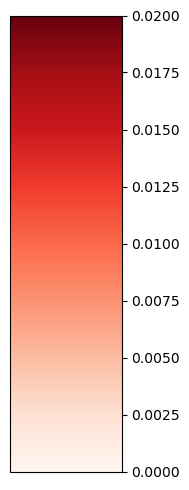

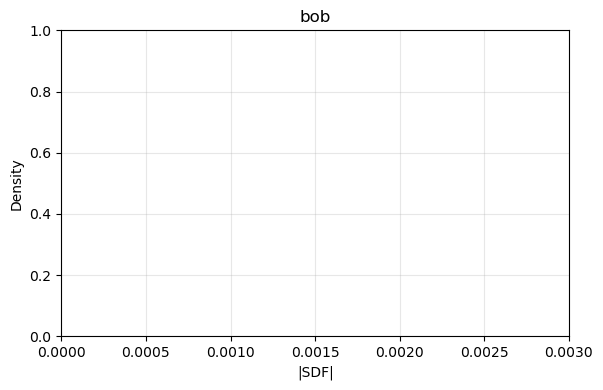

writing to  rendering/rendering_results/errormaps/bob.ply


In [1]:
import trimesh
import numpy as np
import open3d as o3d
import torch

import numpy as np
import torch
import trimesh
import open3d as o3d
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

import json
from tqdm import tqdm

from implicit_reps import *
from visuals import *


cmap = cm.get_cmap("Reds")  # or "Reds", "magma", etc.
device = 'mps'

config_filepath = "configs/surfaces/bob500.json"
result_filepath = "rendering/rendering_results/teaser/bob500/normals.ply"

config_filepath = "configs/surfaces/urchin210.json"
result_filepath = "rendering/rendering_results/urchin-normals.ply"

#config_filepath = "configs/surfaces/mobius220.json"
#result_filepath = "data/surfaces/mobius220-v7.obj"



filepath_dict   = {      'igea-djuren' : ("configs/surfaces/igea500.json", "data/surfaces/igea500-djuren.obj", _ ),
                   'fertility-djuren' : ("configs/surfaces/fertility500.json", "data/surfaces/fertility500-djuren.obj", _ ),
                   'bob-djuren' : ("configs/surfaces/bob500.json", "data/surfaces/bob500-djuren.obj", _ ),
                   'twisted_torus-djuren' : ("configs/surfaces/twisted_torus500.json", "data/surfaces/twisted_torus500-djuren.obj", _ ),
    
                        'fertility' : ("configs/surfaces/fertility500-inv-exp.json", "rendering/rendering_results/teaser/fertility500/normals.ply", "rendering/rendering_results/fertility500-errormap.png" ),
                   
                        'igea' : ("configs/surfaces/igea500.json", "rendering/rendering_results/teaser/igea500/normals.ply", "rendering/rendering_results/igea500-errormap.png" ),
                   
                         'bob' : ("configs/surfaces/bob500.json", "rendering/rendering_results/teaser/bob500/normals.ply", "rendering/rendering_results/bob500-errormap.png" ),
                   
                               'twisted_torus': ("configs/surfaces/twisted_torus500.json", "rendering/rendering_results/teaser/twisted_torus500/normals.ply", "rendering/rendering_results/twisted_torus500-errormap.png" )       }




for identifier in ['bob']:##['bob-djuren', 'bob', 'fertility', 'fertility-djuren', 'twisted_torus', 'twisted_torus-djuren']: ##['fertility', 'igea', 'bob', 'twisted_torus']:
    config_filepath, result_filepath, output_filepath = filepath_dict[identifier]
    
    
    with open(config_filepath, "r") as f:
        config_dict = json.load(f)
        namestring = stringify_config(config_dict)
        print('Namestring will be ', namestring)
    
        shape_name = config_dict['shape-name']
        surface_config = config_dict['surface-config']
        training_config = config_dict['training-config']
    
    if 'sdf_weights_path' in training_config.keys():
        DEEPSDF_MODEL = load_deepsdf_model(
            ckpt_path='sdf_weights/surfaces/' + training_config['sdf_weights_path'],
            device=device
        )
    else:
        DEEPSDF_MODEL = None
    
    if 'sdf_transition_width' in training_config.keys():
        transition_width = training_config['sdf_transition_width']
    else:
        transition_width = 0.0
    
    # ---- Load mesh ----
    mesh_tm = trimesh.load(result_filepath, process=False)
    vertices = mesh_tm.vertices  # (N, 3)
    num_verts = vertices.shape[0]
    
    # ---- Compute SDF (STRICT LOOP, CONSTANT MEMORY) ----
    batch_size = 1000  # safe for MPS, lower if needed
    sdf_vals = np.empty(num_verts, dtype=np.float32)
    
    num_verts = vertices.shape[0]
    batch_size = 8192  # adjust if needed
    
    sdf_vals = np.zeros(num_verts, dtype=np.float32)
    
    with torch.no_grad():
        for start in tqdm(
            range(0, num_verts, batch_size),
            desc="Computing SDF",
            unit="verts",
            total=(num_verts + batch_size - 1) // batch_size,
        ):
            end = min(start + batch_size, num_verts)
    
            v_batch = torch.from_numpy(vertices[start:end]).float().to(device)
            v_batch = v_batch.unsqueeze(0)  # [1, B, 3]
    
            sdf_batch = sdf(
                v_batch,
                sdf_id=training_config['sdf_id'],
                squared=False,
                model=DEEPSDF_MODEL,
                transition_width=transition_width,
            )
    
            sdf_vals[start:end] = (
                sdf_batch.squeeze(0)
                .detach()
                .cpu()
                .numpy()
                .reshape(-1)
            )
    
            del v_batch, sdf_batch
    
    
    
    # ---- Use absolute SDF ----
    abs_sdf = np.abs(sdf_vals)
    
    import matplotlib.colors as mcolors
    import matplotlib.cm as cm
    
    # ---- Explicit log range (YOU CONTROL THIS) ----
    ###vmin = 1e-7
    ###vmax = 1e-2
    
    ###  norm = mcolors.LogNorm(vmin=vmin, vmax=vmax, clip=True)
    

    const = 50
    scale = lambda x : x*const
    
    error_colours = cmap(scale(abs_sdf))[:, :3]
    
    # ---- Linear colorbar range ----
    vmin = 0.0
    vmax = 1.0 / const
    
    
    norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
    
    # ---- Create figure ----
    fig, ax = plt.subplots(figsize=(2, 5))
    
    sm = cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])  # required for ScalarMappable
    
    cbar = plt.colorbar(sm, cax=ax)
    
    plt.savefig(f"rendering/rendering_results/errormaps/cbar.pdf", format="pdf", bbox_inches="tight")
    plt.tight_layout()
    plt.show()
    
    
    
    
    # ---- Open3D mesh ----
    mesh_o3d = o3d.geometry.TriangleMesh(
        vertices=o3d.utility.Vector3dVector(vertices),
        triangles=o3d.utility.Vector3iVector(mesh_tm.faces),
    )
    
    mesh_o3d.vertex_colors = o3d.utility.Vector3dVector(error_colours)
    mesh_o3d.compute_vertex_normals()
    
    # ---- Visualize ----
    o3d.visualization.draw_geometries(
        [mesh_o3d],
        mesh_show_back_face=True,
    )
    
    
    
    
    
    # ---- Histogram of |SDF| ----
    plt.figure(figsize=(6, 4))
    if identifier=='igea':
        plt.hist(
            abs_sdf,
            bins=200,
            density=True,
            log=False,        # very useful for SDF tails
        )
    
    plt.xlabel("|SDF|")
    plt.ylabel("Density")
    plt.title(identifier)
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.xlim(0, 0.003)
    
    # save as PDF
    plt.savefig(f"rendering/rendering_results/errormaps/{identifier}-hist.pdf", format="pdf", bbox_inches="tight")
    
    plt.show()
    
    
    
    # Scalar/Vector dictionary
    colouringdict = {"error_colours": error_colours }
    
    # Write Hakowan-compatible PLY
    
    write_custom_colour_ply_file(
        tm=mesh_tm,
        colouringdict=colouringdict,
        filepath=  f"rendering/rendering_results/errormaps/{identifier}.ply"
    )
    
    








In [2]:
sdf_vals

array([-4.6359375e-05, -7.1708113e-05, -7.2823837e-05, ...,
       -1.2934208e-04,  3.8340688e-05, -2.7721003e-04], dtype=float32)